In [1]:
%matplotlib widget
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Adjust filename
filename = r"lyso cds24B coinc_ALL.csv"

# Read ONLY the first 11 rows
# preamble = pd.read_csv(filename, nrows=9)
with open(filename) as f:
    skiprows= 0
    timeout = 100
    while skiprows < timeout:
        line = next(f).strip().split(",")
        print("\t".join(line))
        if line[0].lower()=="time":
            skiprows-=1
            break
        skiprows += 1
        


Model	MSO64B
Channel	CH1		Channel	CH2		Channel	CH3		Channel	CH4
Waveform Type	ANALOG		Waveform Type	ANALOG		Waveform Type	ANALOG		Waveform Type	ANALOG
Horizontal Units	s		Horizontal Units	s		Horizontal Units	s		Horizontal Units	s
Sample Interval	4.00000000e-11		Sample Interval	4.00000000e-11		Sample Interval	4.00000000e-11		Sample Interval	4.00000000e-11
Record Length	10000		Record Length	10000		Record Length	10000		Record Length	10000
Zero Index	3199.03125000		Zero Index	3199.03125000		Zero Index	3199.03125000		Zero Index	3199.03125000
Vertical Units	V		Vertical Units	V		Vertical Units	V		Vertical Units	V
FastFrame Count	5000		FastFrame Count	5000		FastFrame Count	5000		FastFrame Count	5000
ANALOG_Thumbnail			ANALOG_Thumbnail			ANALOG_Thumbnail			ANALOG_Thumbnail	

TIME	CH1	CH2	CH3	CH4


In [2]:
df = pd.read_csv(filename, skiprows=skiprows)

df.head()

# 2. Find reset points
time_diff = df.iloc[:, 0].diff()
reset_points = time_diff < 0
reset_indices = reset_points[reset_points].index.to_list()

# 3. Start and end indices
trace_starts = [0] + reset_indices
trace_ends = trace_starts[1:] + [len(df)]

# 4. Split
traces_list = [
    df.iloc[start:end].reset_index(drop=True).sort_values(by = "TIME")
    for start, end in zip(trace_starts, trace_ends)
]

print(f"Found {len(traces_list)} traces")

Found 5000 traces


In [5]:
data_array = df.to_numpy()

# Reshape into (5000 traces, 10000 points per trace, 5 columns)
traces = np.stack([trace.to_numpy() for trace in traces_list])

traces.shape


(5000, 10000, 5)

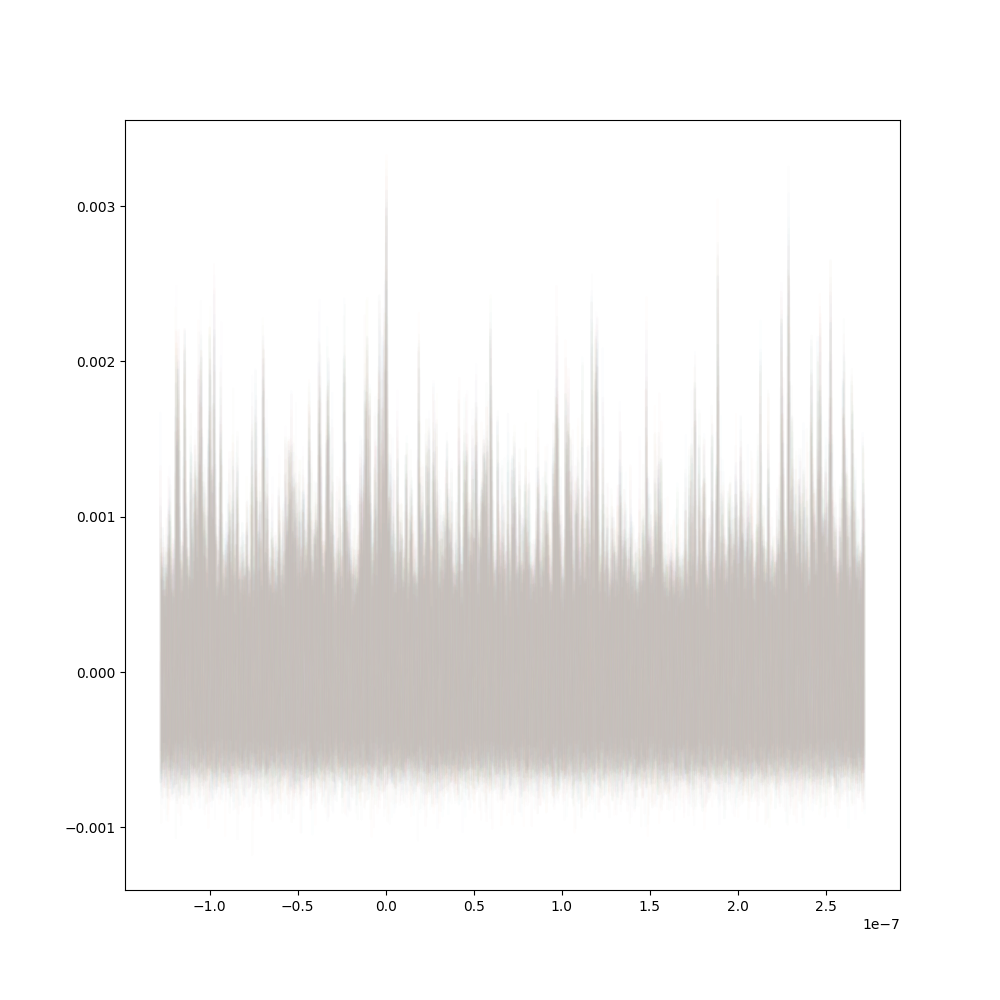

In [6]:
import matplotlib.pyplot as plt
channel_data = traces[:, :, 1]

n_bins = 500
vmin = channel_data.min()
vmax = channel_data.max()
bins = np.linspace(vmin, vmax, n_bins + 1)

def hist_counts(col):
    counts, _ = np.histogram(col, bins=bins)
    return counts

# Apply
heatmap = np.apply_along_axis(hist_counts, axis=0, arr=channel_data.T)

plt.figure(figsize = (10,10))
# plt.imshow(heatmap, aspect = 10)
plt.plot(traces[0:1000,:,0], traces[0:1000,:,3], alpha = 0.01)
plt.show()

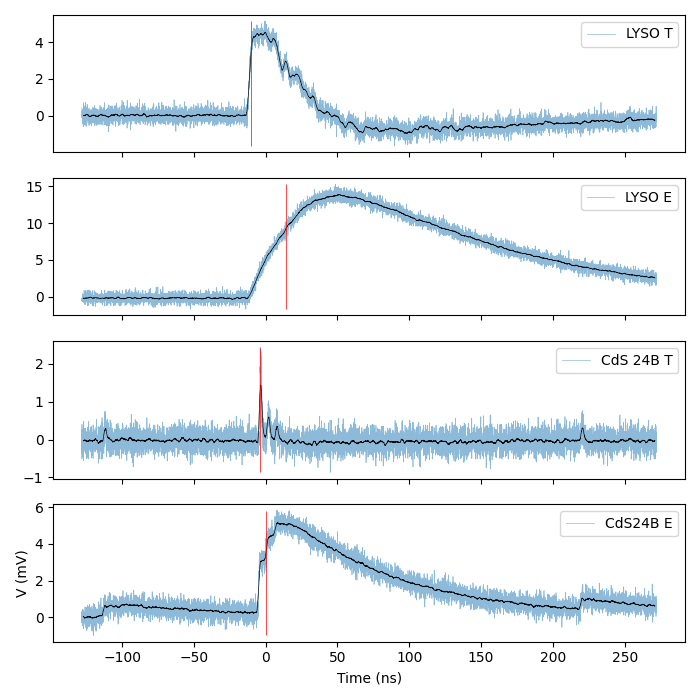

[-6.24]
[14.120000000000001]
25


In [8]:
def moving_average(y, window_size):
    return np.convolve(y, np.ones(window_size)/window_size, mode='valid')

def trigger_pulse(xs,ys,ax,dt = 1e-5, label = "Signal"):
    maxs = moving_average(xs, window)
    mays = moving_average(ys, window)

    dys = np.diff(mays)
    dt = max(mays)/1.5
    # print(dt)
    # trigger_x = maxs[mays>dt][0]
    try:
        trigger_x = maxs[mays>dt][0]
    except:
        print(f"Error: max V {max(mays)}")
        trigger_x = max(mays)/4
    if ax:
        ax.plot(xs, ys, alpha = 0.5, lw = 0.5, label = label)
        ax.plot(maxs, mays,'k', alpha = 0.95, lw = 0.5)
        # ax.plot(maxs[1:], dys,'r', alpha = 0.75, lw = 0.5)
        ax.vlines(trigger_x, min(ys), max(ys), lw = 0.5, color = 'r')
        ax.legend()
    return trigger_x

hits = 0
window = 50
fig,axes = plt.subplots(4,1,figsize = (7,7), sharex = True)
# plt.imshow(heatmap, aspect = 10)
dfts = []
dets = []
for i in range(traces.shape[0]):
    if any(traces[i,:,1]>0.002) and any(traces[i,:,3]>0.001):
        t1 = trigger_pulse(traces[i,:,0]*1e9, traces[i,:,1]*1e3,None, dt = 0.5, label="LYSO T")
        t3 = trigger_pulse(traces[i,:,0]*1e9, traces[i,:,3]*1e3,None, dt = 3, label="EJ232 T")
        if abs(t1-t3) < 10 and t1<t3:
            t1 = trigger_pulse(traces[i,:,0]*1e9, traces[i,:,1]*1e3,axes[0], dt = 0.5, label="LYSO T")
            t3 = trigger_pulse(traces[i,:,0]*1e9, traces[i,:,3]*1e3,axes[2], dt = 3, label="CdS 24B T")
            t2 = trigger_pulse(traces[i,:,0]*1e9, traces[i,:,2]*1e3,axes[1], dt = 0.1, label="LYSO E")
            t4 = trigger_pulse(traces[i,:,0]*1e9, traces[i,:,4]*1e3,axes[3], dt = 10, label="CdS24B E")
            dfts.append(t1-t3)
            dets.append(t2-t4)
            break
        
        hits+=1
plt.xlabel("Time (ns)")
plt.ylabel("V (mV)")
plt.tight_layout()
plt.savefig("LYSO_24B_trigger.svg",format = "svg")
plt.show()
print(dfts)
print(dets)
print(hits)